In [24]:
# ============================================================
# Cell 1: Imports & Setup
# ============================================================

# Python Standard Libraries
import os                       # os.getcwd(), os.path.join()

# External Libraries
import numpy as np              # np.array(), np.mean(), np.std()
import matplotlib.pyplot as plt # plt.imread(),plt.imshow(), plt.show(), plt.axis('off'),
import pandas as pd             
import cv2                      # cv2.imread(), cv2.cvtColor(), cv2.COLOR_BGR2RGB, cv2.COLOR_BGR2HSV, cv2.COLOR_BGR2LAB, cv2.COLOR_BGR2YCrCb


# Pytorch Libraries
import torch
import torch.nn as nn

Ayeaye! Img Shape: (363, 360, 3)


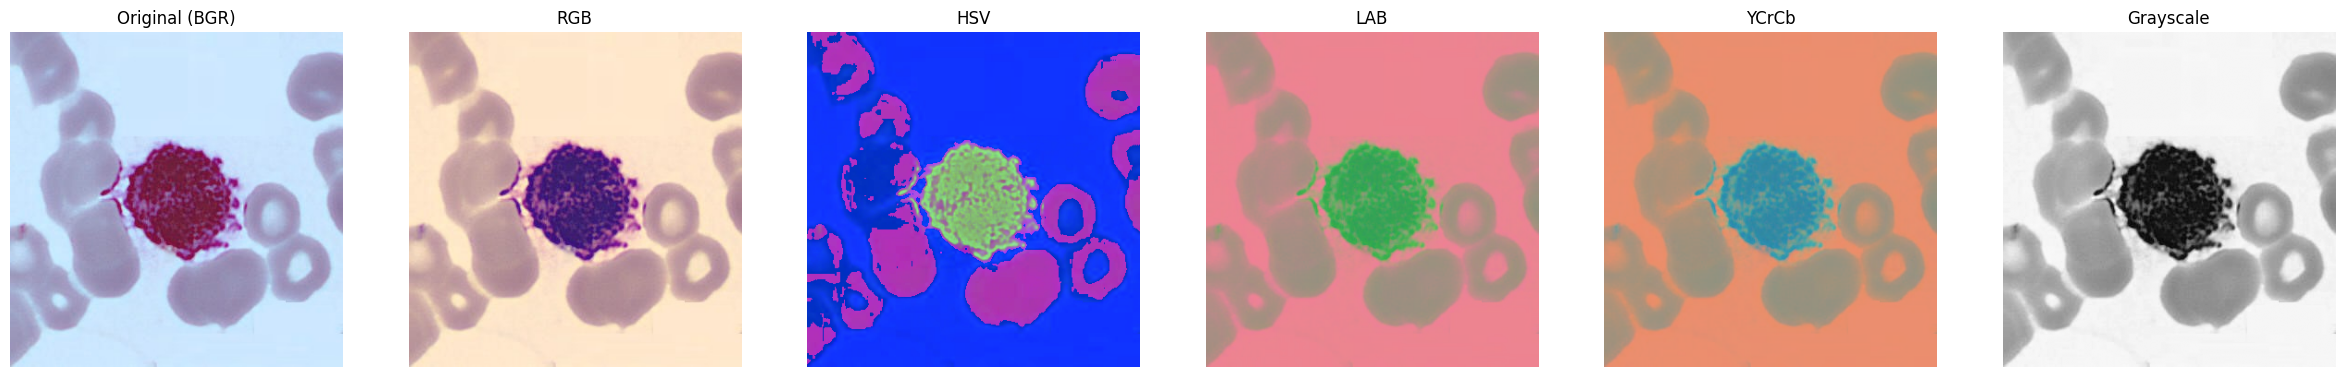

C:\Users\User1\Documents\GitHub\IIP-G8\Dataset & Ground Truth\Naturalize Dataset\Naturalize Dataset\BA\BA 2k-PBC Train (58).jpg
C:\Users\User1\Documents\GitHub\IIP-G8\Dataset & Ground Truth\Naturalize Dataset\Naturalize Dataset
c:\Users\User1\Documents\GitHub\IIP-G8


In [ ]:
# ============================================================
# Cell 2: Image Color Space Check
# ============================================================
ROOT_DIR = r"C:\Users\User1\Documents\GitHub\IIP-G8\Dataset & Ground Truth\Naturalize Dataset\Naturalize Dataset"
FILE_DIR = os.getcwd()

TEST_ = os.path.join(ROOT_DIR, r"BA\BA 2k-PBC Train (58).jpg")
img = cv2.imread(TEST_IMG)

if img is None  : print(f"Error: Couldn't load image path: {TEST_IMG}")
else            : print(f"Ayeaye! Img Shape: {img.shape}")


def show_colorspace_image(number, image, title, color_model, cmap=None):
    """
    Function show_colorspace_image: Prepares images to be displayed for plt.show() call.
        Parameters:
        - number: Number it sequentially from 0-n.
        - image: Pass img or the base image (remember to convert from its respective color space).
        - title: Title of converted color space.
        - color_model: Color space chosen.
    """
    if color_model is not None:
            image = cv2.cvtColor(image, color_model)
    
    axes[number].imshow(image, cmap=cmap)
    axes[number].set_title(title)
    axes[number].axis('off')

# Figure Creation
figs, axes = plt.subplots(1, 6, figsize=(30, 5))

show_colorspace_image(0, img, "Original (BGR)", None)
show_colorspace_image(1, img, "RGB", cv2.COLOR_BGR2RGB)
show_colorspace_image(2, img, "HSV", cv2.COLOR_BGR2HSV)
show_colorspace_image(3, img, "LAB", cv2.COLOR_BGR2LAB)
show_colorspace_image(4, img, "YCrCb", cv2.COLOR_BGR2YCrCb)
show_colorspace_image(5, img, "Grayscale", cv2.COLOR_BGR2GRAY, "gray")

plt.show()

# Root Checks
print(TEST_IMG)
print(ROOT_DIR)
print(FILE_DIR)


#### - HSV is definitely worth considering, between it and grayscale/LAB

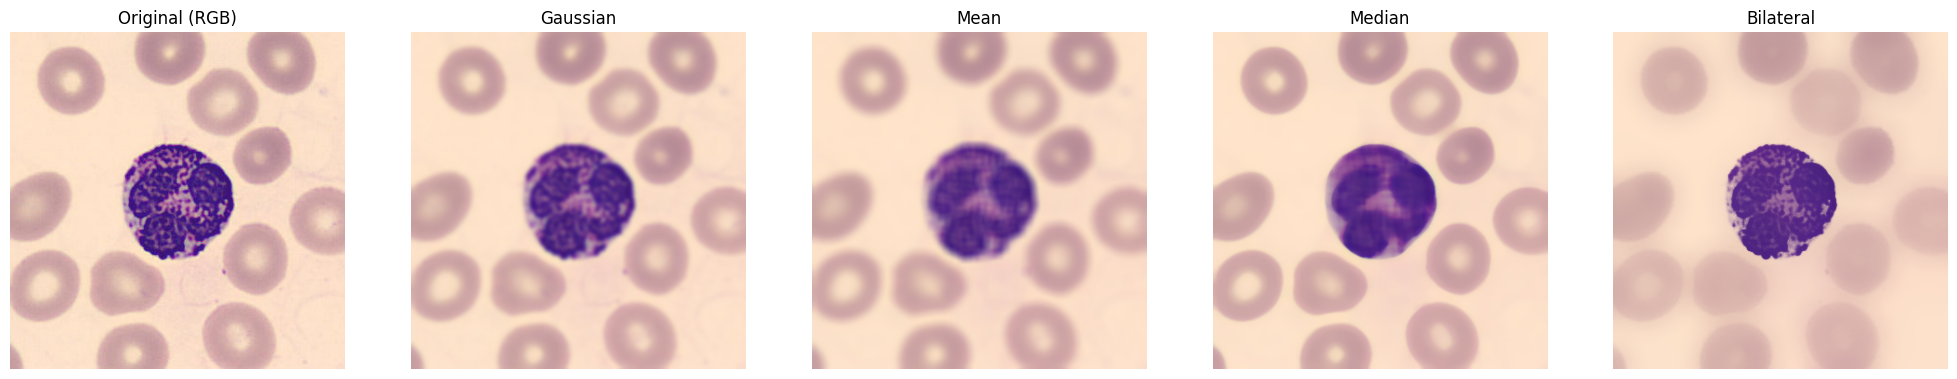

In [ ]:
# ============================================================
# Cell 3: Image Color Space Check
#
# Convert the original BGR image to RGB so it looks correct in matplotlib
# ============================================================
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def show_filtered_image(number, image, title, filter_type=None):
    """
    Function show_filtered_image: Prepares images to be displayed for plt.show() call.
        Parameters:
        - number: Number it sequentially from 0-n.
        - image: The base image to apply the filter to.
        - title: Title of the filter.
        - filter_type: Type of noise reduction filter to apply.
    """
    
    if filter_type == "gaussian":
        """
        cv2.GaussianBlur(src, ksize, sigmaX)
        ksize = Kernel Size (Linear dimensions for the square window used to calculate the median value. - Only ODD Positive Numbers).
        sigmaX = Std. Dev. for gaussian dist. across X-axis. (bigger = more blurring)
        """
        image = cv2.GaussianBlur(image, (11, 11), 2)

    elif filter_type == "mean":
        # cv2.blur(src, ksize)
        image = cv2.blur(image, (11, 11))

    elif filter_type == "median":
        # cv2.medianBlur(src, ksize).
        image = cv2.medianBlur(image, 15)

    elif filter_type == "bilateral":
        """ 
        cv2.bilateralFilter(src, d, sigmaColor, sigmaSpace)
        d = Diameter of Neighborhood (defines how large the area is around each pixel that is considered for the blurring calculation.)
        signaColor = determines how dissimilar colors/intensities can be before they are ignored during the filtering process.
        sigmaSpace = Same as sigmaColor but for spatial coordinates/space.
        """ 
        image = cv2.bilateralFilter(image, 50, 110, 110)
        
    axes[number].imshow(image)
    axes[number].set_title(title)
    axes[number].axis('off')
    
# Figure Creation
figs, axes = plt.subplots(1, 5, figsize=(25, 5))

show_filtered_image(0, img_rgb, "Original (RGB)", None)
show_filtered_image(1, img_rgb, "Gaussian", "gaussian")
show_filtered_image(2, img_rgb, "Mean", "mean")
show_filtered_image(3, img_rgb, "Median", "median")
show_filtered_image(4, img_rgb, "Bilateral", "bilateral")

plt.show()

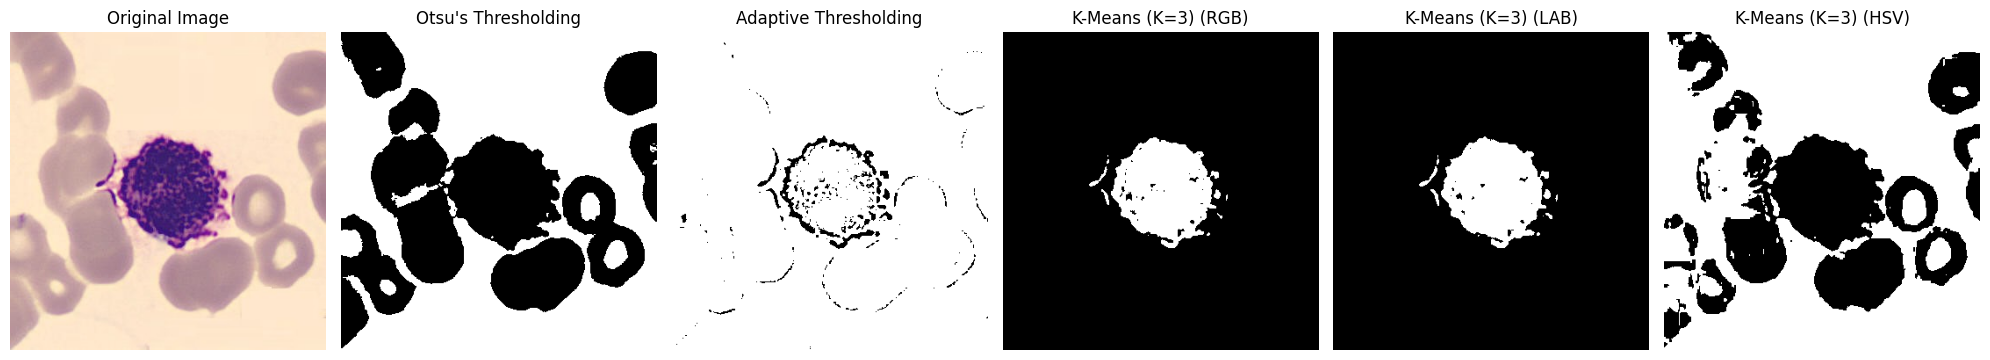

In [111]:
# ============================================================
# Cell 4: Thresholding & Segmentation Techniques
# ============================================================

def show_thresholded_image(number, image, title, method, k=3):
    """
    Applies a segmentation method and plots it on the current 'axes'.
    method choices: "otsu", "adaptive", "kmeans"
    k: Number of clusters (Only used for K-Means)
    """
    
    if method == "otsu":
        # Otsu requires a single-channel (grayscale) image
        if len(image.shape) == 3:
            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        else:
            gray = image
            
        # Apply Otsu's thresholding
        ret, result = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        
    elif method == "adaptive":
        # Adaptive Thresholding requires single-channel
        if len(image.shape) == 3:
            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        else:
            gray = image
            
        # Block size=11, C=2 (These are standard defaults, but can be tweaked)
        result = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                       cv2.THRESH_BINARY, 25, 16)
        
    elif method == "kmeans":
        # K-Means requires an array of pixels (N x 3)
        pixel_values = image.reshape((-1, 3))
        pixel_values = np.float32(pixel_values)
        
        # Define stopping criteria: Max 20 iterations OR epsilon accuracy of 0.3
        criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 20, 0.3)
        
        # Apply K-Means
        _, labels, centers = cv2.kmeans(pixel_values, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
        
        # Stained cell nuclei are the darkest cluster
        center_brightness = np.sum(centers, axis = 1)
        fg_cluster = np.argmin(center_brightness)

        labels_flat = labels.flatten()
        mask = np.where(labels_flat == fg_cluster, 255, 0).astype(np.uint8)

        result = mask.reshape(image.shape[:2])

    # --- Plotting Logic ---
    # Check if the result has only 2 dimensions (binary/grayscale)
    if len(result.shape) == 2:
        axes[number].imshow(result, cmap='gray')
    else:
        axes[number].imshow(result)
        
    axes[number].set_title(title)
    axes[number].axis('off')

# Figure Creation: 1 row, 6 columns
figs, axes = plt.subplots(1, 6, figsize=(20, 5))

# Plot the original image for reference
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_LAB = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
img_HSV = cv2.cvtColor(img, cv2.COLOR_BGR2HSV_FULL)

axes[0].imshow(img_rgb)
axes[0].set_title("Original Image")
axes[0].axis('off')

# Call your new function!
show_thresholded_image(1, img_rgb, "Otsu's Thresholding", method="otsu")
show_thresholded_image(2, img_rgb, "Adaptive Thresholding", method="adaptive")

# K=3 or K=4 usually works well for blood cells (Nucleus, Cytoplasm, RBCs, Background)
show_thresholded_image(3, img_rgb, "K-Means (K=3) (RGB)", method="kmeans", k=3)
show_thresholded_image(4, img_LAB, "K-Means (K=3) (LAB)", method="kmeans", k=3)
show_thresholded_image(5, img_HSV, "K-Means (K=3) (HSV)", method="kmeans", k=3)

plt.tight_layout()
plt.show()


In [201]:
# ============================================================
# Cell 5: Helper Functions for Noise Reduction, Thresholding, Binary Processing & Eval Metric w/ Ground Truth
# ============================================================

def apply_noise_reduction(image, method="raw"):
    """Applies a noise reduction filter to an image before segmentation."""
    if method == "gaussian":
        # Gaussian Blur: Standard, smooth blur
        return cv2.GaussianBlur(image, (13, 13), 12)
        
    elif method == "median":
        # Median Blur: Fantastic at removing grainy noise while preserving hard cell edges
        return cv2.medianBlur(image, 35)
        
    elif method == "bilateral":
        # Bilateral Filter: Blurs the inside of the cell but perfectly preserves borders
        # Parameters: Diameter=9, SigmaColor=75, SigmaSpace=75
        return cv2.bilateralFilter(image, 55, 150, 150)
    
    # "raw" returns the completely unmodified image
    return image

# ============================================================

def get_thresholded_mask(image, method="otsu", k=3):
    """Returns ONLY the raw binary mask calculated by the specified method."""
    if method == "otsu":
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) if len(image.shape) == 3 else image
        _, result = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        return result
        
    elif method == "adaptive":
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) if len(image.shape) == 3 else image
        result = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 25, 16)
        return result
        
    elif method == "kmeans":
        pixel_values = image.reshape((-1, 3)) if len(image.shape) == 3 else image.reshape((-1, 1))
        pixel_values = np.float32(pixel_values)
        
        criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.7)
        _, labels, centers = cv2.kmeans(pixel_values, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
        
        center_brightness = np.sum(centers, axis=1)
        fg_cluster = np.argmin(center_brightness)

        labels_flat = labels.flatten()
        mask = np.where(labels_flat == fg_cluster, 255, 0).astype(np.uint8)
        return mask.reshape(image.shape[:2])

# ============================================================

def apply_binary_processing(mask, method="closing", kernel_size=(7,7)):
    """
    Applies binary cleanup techniques to a black-and-white mask.
    method: "opening", "closing", "opening_closing", "connected_components", "contour_filtering"
    """
    # Create an elliptical kernel for morphology
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, kernel_size)
    
    if method == "opening":
        # Opening (Erosion -> Dilation): Erases small white noise patches 
        return cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=2)
        
    elif method == "closing":
        # Closing (Dilation -> Erosion): Fills small black holes inside white bodies
        return cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
        
    elif method == "opening_closing":
        # Does both: Erases tiny noise FIRST, then fills holes inside the remaining cells
        opened = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
        closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel, iterations=2)
        return closed
        
    elif method == "connected_components":
        # 1. Identifies all separate white shapes in the image
        num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask, connectivity=8)
        
        # 2. Blank canvas to accept surviving objects
        cleaned_mask = np.zeros_like(mask)
        
        # 3. Loop through all found components (skipping 0, which is the black background)
        for i in range(1, num_labels):
            area = stats[i, cv2.CC_STAT_AREA]
            
            # If the area is large enough to be a PMY nucleus (e.g. > 1000 pixels)
            # You may need to tweak this 1000 value depending on image resolution!
            if area > 1000:
                cleaned_mask[labels == i] = 255
                
        return cleaned_mask
        
    elif method == "contour_filtering":
        # 1. Find the outer boundary lines of all white blobs
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        # 2. Blank canvas
        cleaned_mask = np.zeros_like(mask)
        
        for contour in contours:
            area = cv2.contourArea(contour)
            if area > 1000:  
                # Draw the contour filled in (thickness=-1). This has the added 
                # bonus of automatically filling any internal holes!
                cv2.drawContours(cleaned_mask, [contour], -1, 255, thickness=-1)
                
        return cleaned_mask
    return mask

# ============================================================

def calculate_metrics(predicted_mask, gt_mask):
    """
    Compares a predicted binary mask against a Ground Truth mask
    and returns standard segmentation metrics.
    """
    # 1. Ensure both masks are strictly binary (0s and 1s)
    pred = (predicted_mask > 127).astype(np.uint8)
    gt = (gt_mask > 127).astype(np.uint8)
    
    # 2. Calculate pixel overlaps
    # True Positives (TP): We predicted cell, and it IS a cell
    TP = np.sum((pred == 1) & (gt == 1))
    # False Positives (FP): We predicted cell, but it's actually background
    FP = np.sum((pred == 1) & (gt == 0))
    # False Negatives (FN): We predicted background, but it's actually a cell
    FN = np.sum((pred == 0) & (gt == 1))
    # True Negatives (TN): We predicted background, and it IS background
    TN = np.sum((pred == 0) & (gt == 0))
    
    # 3. Calculate Metrics (Adding 1e-10 prevents division by zero errors)
    iou = TP / (TP + FP + FN + 1e-10)
    dice = (2 * TP) / ((2 * TP) + FP + FN + 1e-10)
    precision = TP / (TP + FP + 1e-10)
    accuracy = (TP + TN) / (TP + TN + FP + FN + 1e-10)
    
    return {
        "IoU": round(iou, 4),
        "Dice Coefficient": round(dice, 4),
        "Precision": round(precision, 4),
        "Accuracy": round(accuracy, 4)
    }

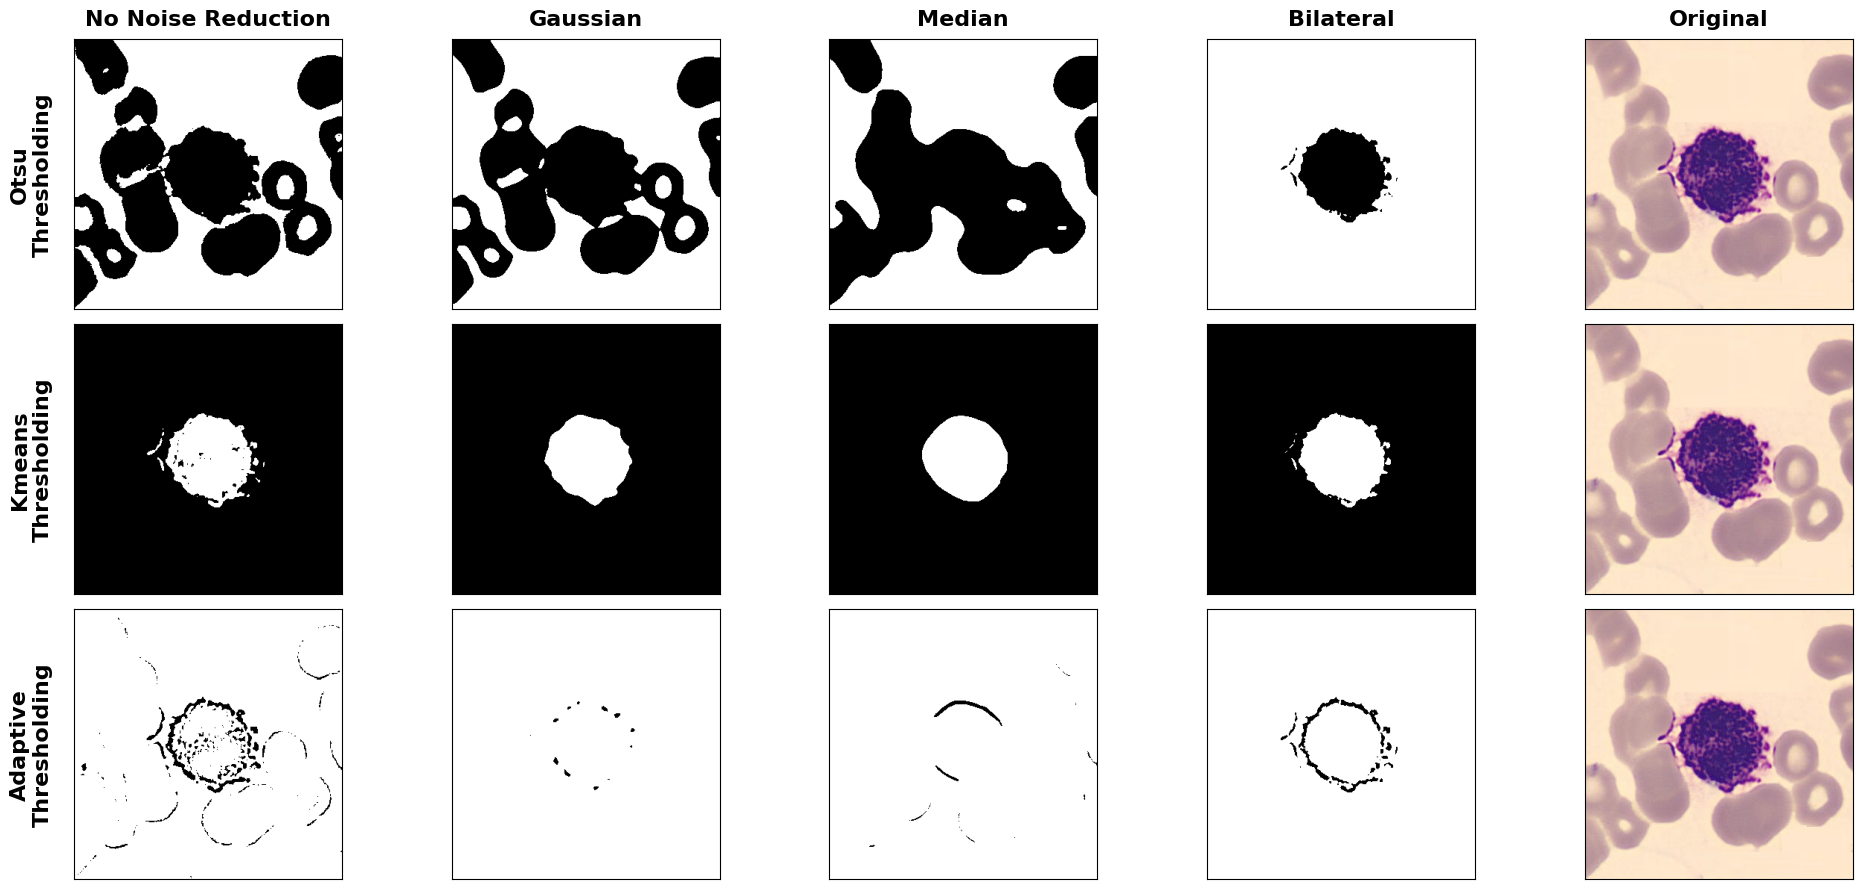

In [ ]:
""" 
Noise Reduction Techniques against Thresholding Techniques.
"""


thresholding_methods = ["otsu", "kmeans", "adaptive"]
# Added 'original' to the end for your reference column!
noise_methods = ["No Noise Reduction", "gaussian", "median", "bilateral", "original"]

figs, axes = plt.subplots(len(thresholding_methods), len(noise_methods), figsize=(20, 9))

for row, t_method in enumerate(thresholding_methods):
    for col, n_method in enumerate(noise_methods):
        ax = axes[row, col]
        
        # 1. Handle the Reference Image Column
        if n_method == "original":
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            ax.imshow(img_rgb)
        
        # 2. Main Logic: Noise Reduction -> Thresholding
        else:
            # Step A: Apply the Noise Reduction
            denoised_img = apply_noise_reduction(img, method=n_method)
            
            # Step B: Feed the denoised image into your thresholding calculator!
            raw_mask = get_thresholded_mask(denoised_img, method=t_method, k=3)
            
            # Plot the resulting mask
            ax.imshow(raw_mask, cmap='gray')
            
        # Disable ticks so the images look clean
        ax.set_xticks([])
        ax.set_yticks([])
        
        # 3. Set the Column Headers (Top Row)
        if row == 0:
            ax.set_title(n_method.title(), fontsize=16, fontweight='bold', pad=10)
            
        # 4. Set the Row Headers (First Column)
        if col == 0:
            ax.set_ylabel(t_method.title() + "\nThresholding", fontsize=16, fontweight='bold', labelpad=15)

plt.tight_layout()
plt.show()

#### - Adaptive Thresholding is removed as it requires extensive fine-tuning.
#### - Median gets disqualified as it doesn't preserve the outer edges as good as Gaussian and Bilateral.


#### - We'll move forward with Gaussian Noise Reduction & Bilateral Noise Reduction as our Noise Reduction methods in addition to Otsu's and K-Means Thresholding as our Thresholding and Segmentation methods.

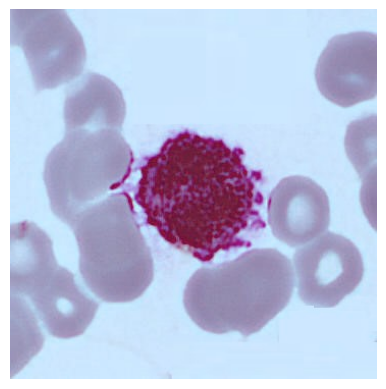

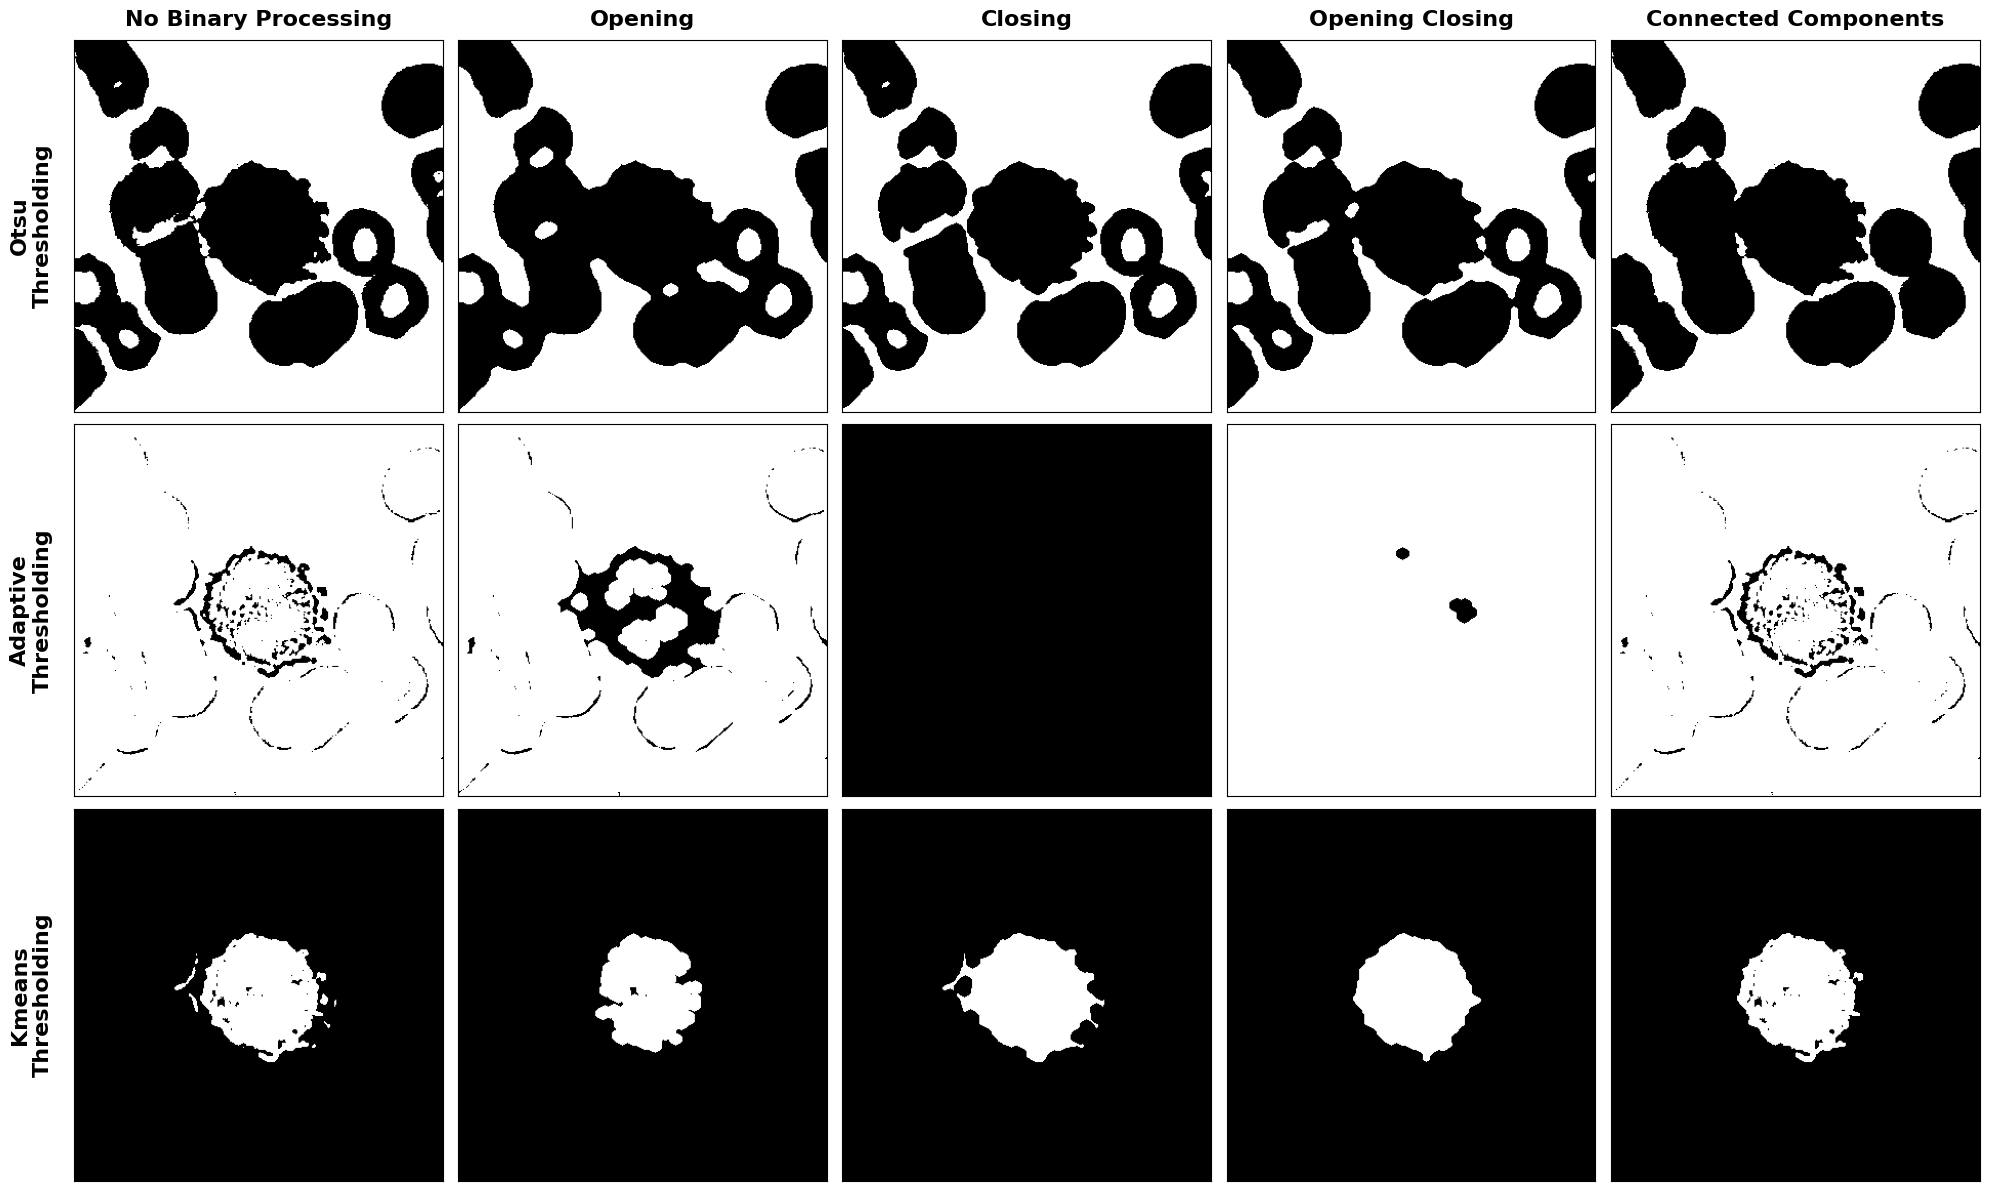

In [ ]:
""" 
Binary Processing Method Against different Thresholding Techniques (Otsu's, Adaptive, K-Means)
"""

thresholding_methods = ["otsu", "adaptive", "kmeans"]
processing_methods = ["No Binary Processing", "opening", "closing", "opening_closing", "connected_components"]

plt.imshow(img)
plt.axis("off")
plt.show()

# Create a wider, shorter grid: 3 rows, 6 columns
figs, axes = plt.subplots(len(thresholding_methods), len(processing_methods), figsize=(20, 12))

# Now we loop through thresholding methods for the ROWS
for row, t_method in enumerate(thresholding_methods):
    
    # 1. Calculate the initial raw mask for this row's thresholding technique
    raw_mask = get_thresholded_mask(img, method=t_method, k=3)
    
    # Then loop through the binary processing cleanup methods for the COLUMNS
    for col, p_method in enumerate(processing_methods):
        
        # 2. Apply the column's cleanup technique
        if p_method == "raw":
            cleaned_mask = raw_mask
        else:
            cleaned_mask = apply_binary_processing(raw_mask, method=p_method, kernel_size=(7,7))
            
        ax = axes[row, col]
        
        # 3. Plot the final mask
        ax.imshow(cleaned_mask, cmap='gray')
        
        # Disable ticks so the images look clean
        ax.set_xticks([])
        ax.set_yticks([])
        
        # 4. Set the Column Headers (on the Top Row of images)
        if row == 0:
            col_title = p_method.replace('_', ' ').title()
            ax.set_title(col_title, fontsize=16, fontweight='bold', pad=10)
            
        # 5. Set the Row Headers (on the First Column of images)
        if col == 0:
            ax.set_ylabel(t_method.title() + "\nThresholding", fontsize=16, fontweight='bold', labelpad=15)

# Adjust layout to make sure labels don't bunch up
plt.tight_layout()
plt.show()

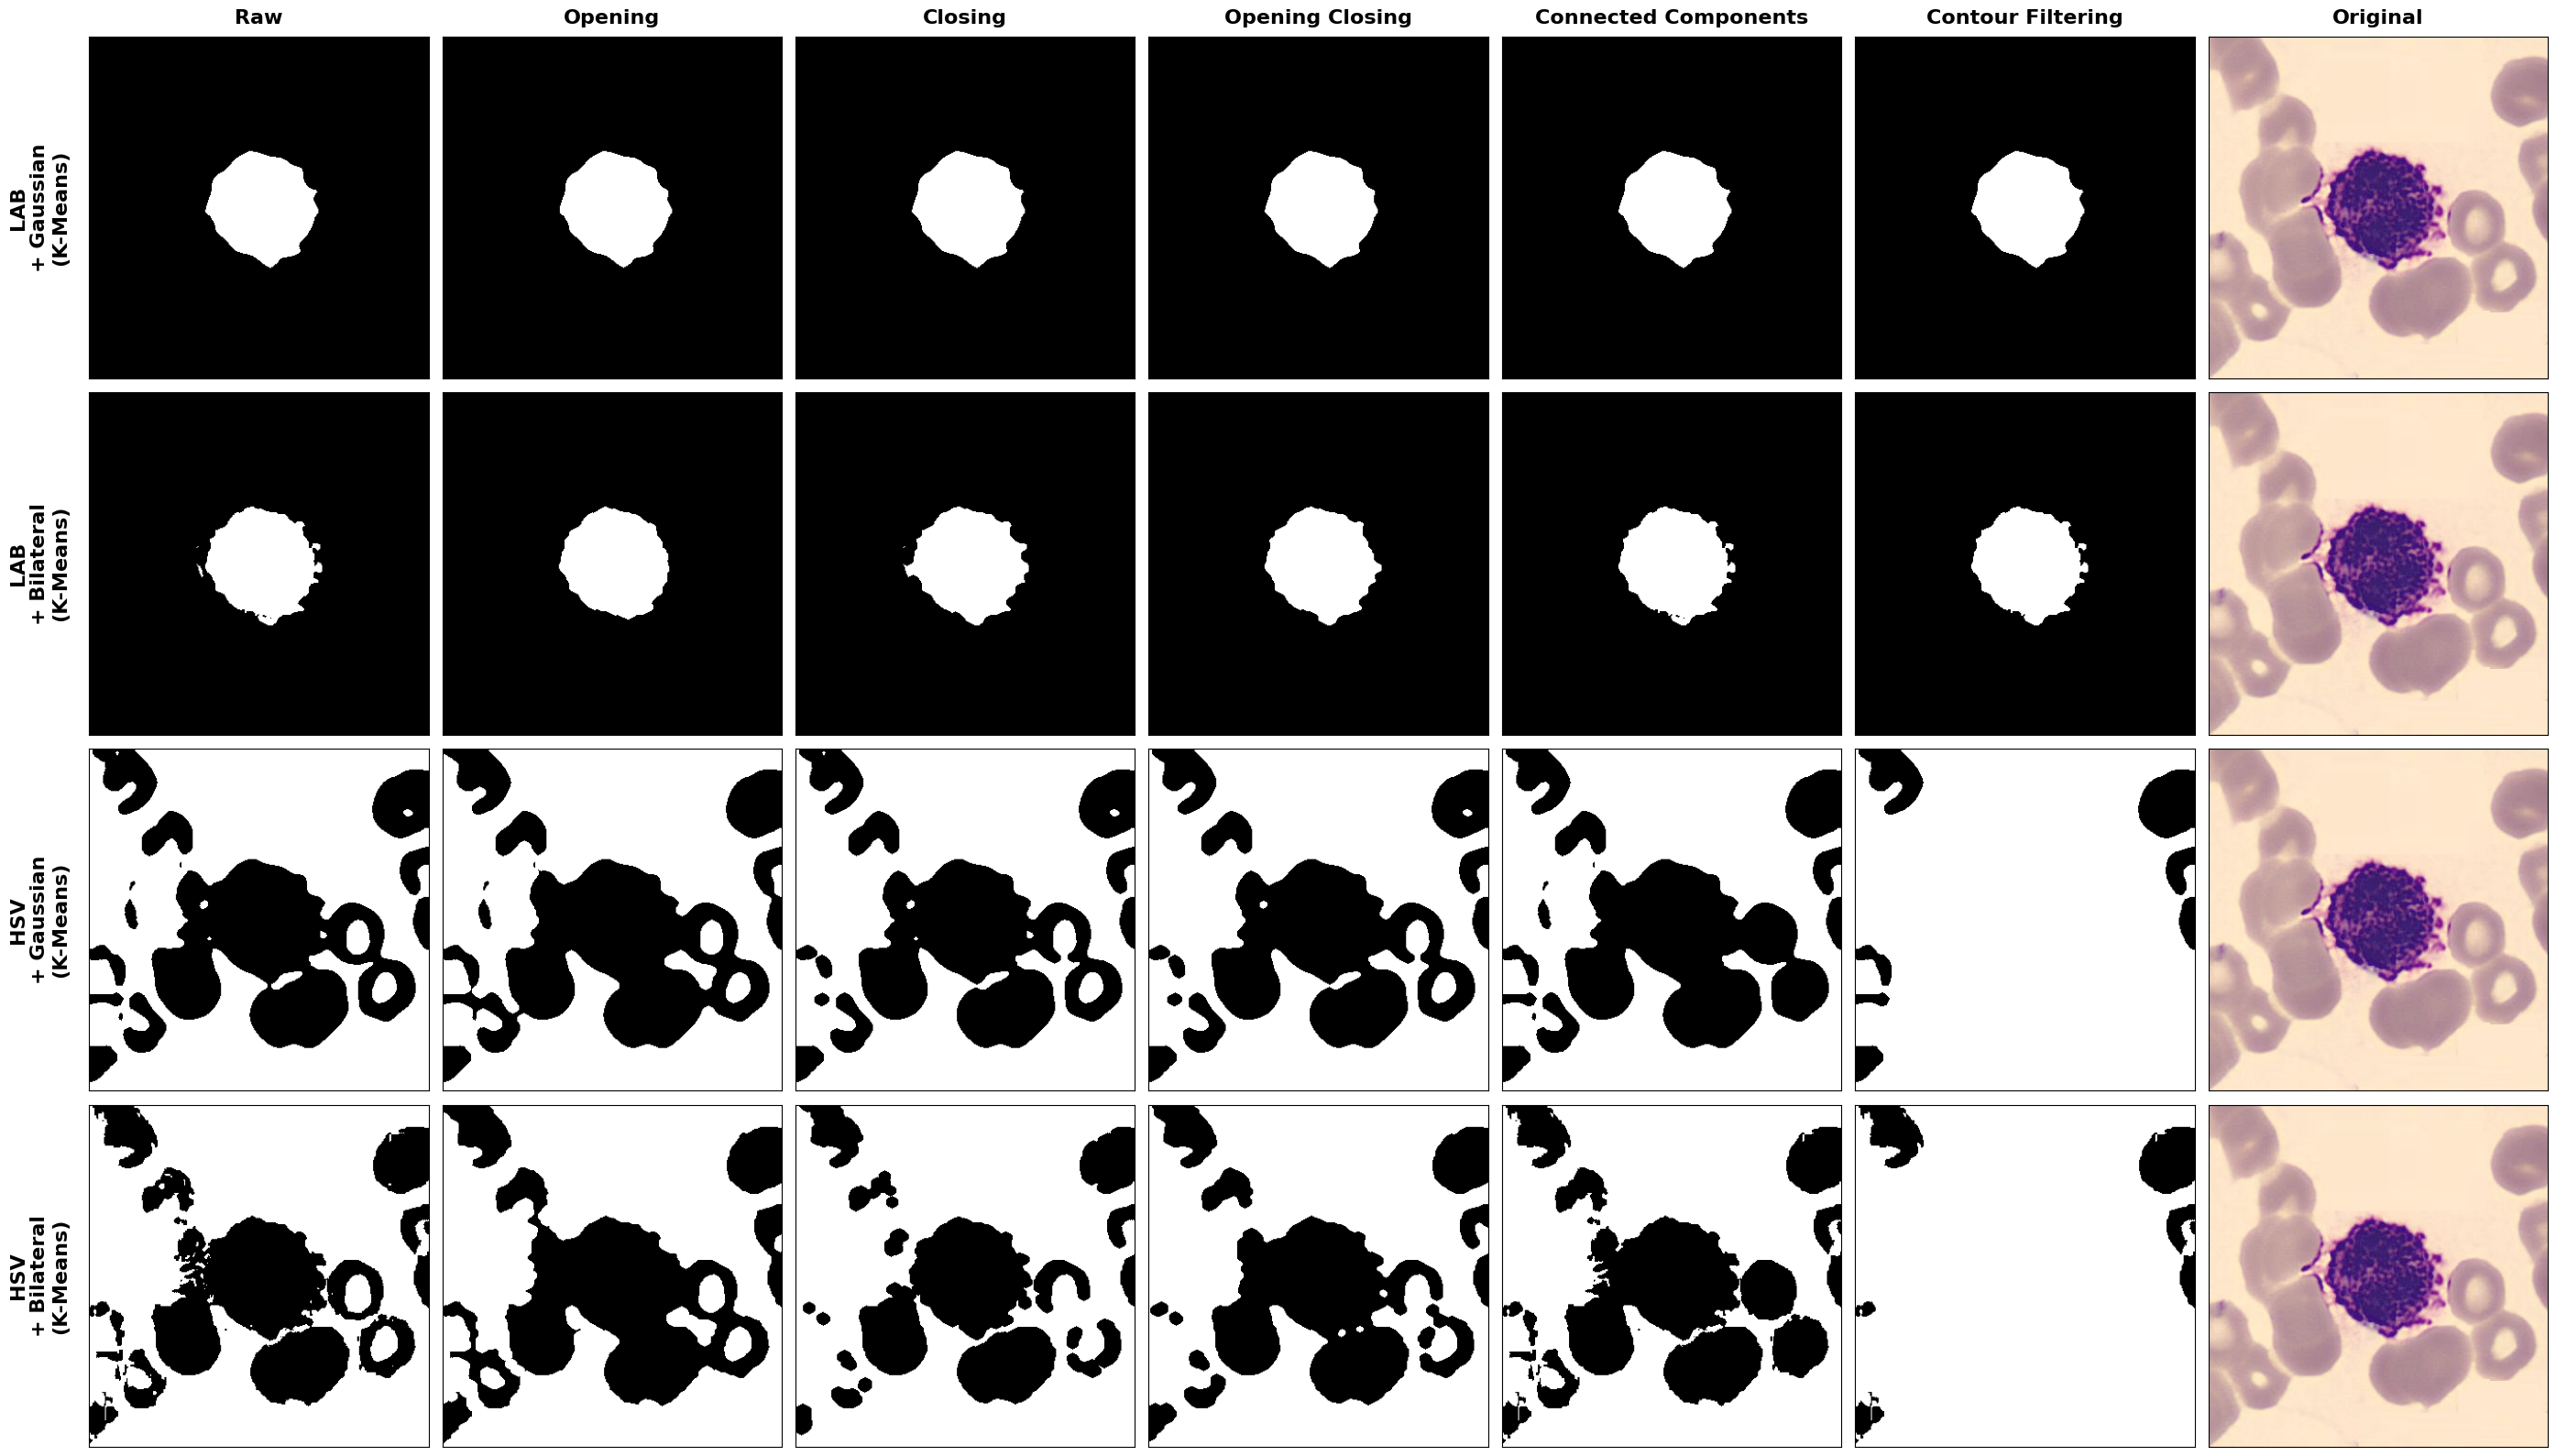

In [ ]:
""" 
Binary Processing Method Against LAB & HSV w/ Noise Reduction (Bilateral & Gaussian)
"""

colorspaces = ["LAB", "HSV"]
noise_reductions = ["gaussian", "bilateral"]
processing_methods = ["raw", "opening", "closing", "opening_closing", "connected_components", "contour_filtering", "original"]

# 4 Rows (LAB+Gaussian, LAB+Bilateral, HSV+Gaussian, HSV+Bilateral) x 7 Columns
figs, axes = plt.subplots(4, len(processing_methods), figsize=(28, 16))

# Keep track of which row we are plotting on
row_idx = 0

for cs in colorspaces:
    # 1. Convert Colour Space
    if cs == "LAB":
        cs_img = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    else:  # HSV
        cs_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        
    for nr in noise_reductions:
        # 2. Apply Noise Reduction to the already-converted colour image
        denoised_cs_img = apply_noise_reduction(cs_img, method=nr)
        
        # 3. Apply K-Means Thresholding (Always K-Means for this grid!)
        raw_mask = get_thresholded_mask(denoised_cs_img, method="kmeans", k=3)
        
        # 4. Sweep across the Horizontal Axis (Columns) applying Binary Processing
        for col, p_method in enumerate(processing_methods):
            ax = axes[row_idx, col]
            
            if p_method == "original":
                # Final column: Plot the reference image
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                ax.imshow(img_rgb)
            else:
                if p_method == "raw":
                    cleaned_mask = raw_mask
                else:
                    # Clean up the mask using the column's logic
                    cleaned_mask = apply_binary_processing(raw_mask, method=p_method, kernel_size=(7,7))
                    
                ax.imshow(cleaned_mask, cmap='gray')
            
            # Disable ticks for cleanly presented images
            ax.set_xticks([])
            ax.set_yticks([])
            
            # Set Column Titles (Top Row Only)
            if row_idx == 0:
                col_title = p_method.replace('_', ' ').title()
                ax.set_title(col_title, fontsize=16, fontweight='bold', pad=10)
                
            # Set Row Labels (First Column Only)
            if col == 0:
                ax.set_ylabel(f"{cs}\n+ {nr.title()}\n(K-Means)", fontsize=16, fontweight='bold', labelpad=15)
                
        # Advance the row counter once a full sweep of the columns finishes
        row_idx += 1

plt.tight_layout()
plt.show()

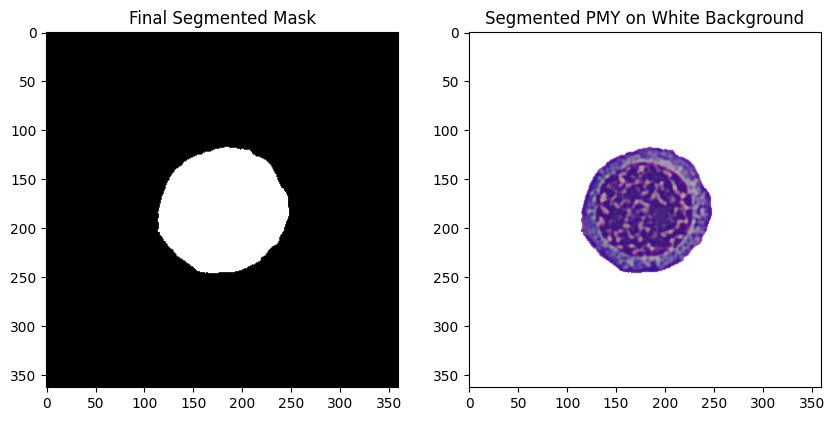

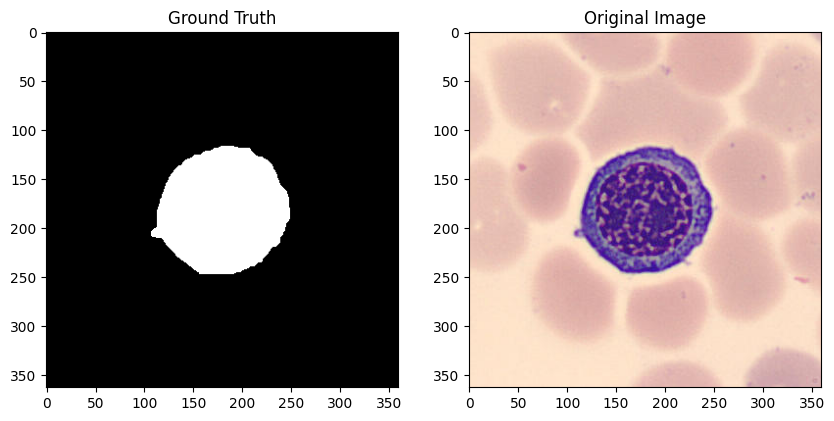

C:\Users\User1\Documents\GitHub\IIP-G8\Dataset & Ground Truth\Naturalize Dataset\Naturalize Dataset\ERB\ERB 2K-PBC Train (473).jpg
C:\Users\User1\Documents\GitHub\IIP-G8\Dataset & Ground Truth\Ground Truth\Ground Truth\ERB\ERB 2K-PBC Train (473)_mask.png

--- Evaluation Results ---
IoU: 95.99%
Dice Coefficient: 97.96000000000001%
Precision: 100.0%
Accuracy: 99.58%


In [ ]:
img1 = cv2.imread(r"C:\Users\User1\Documents\GitHub\IIP-G8\Dataset & Ground Truth\Naturalize Dataset\Naturalize Dataset\BA\BA 2k-PBC Train (58).jpg")
img2 = cv2.imread(r"C:\Users\User1\Documents\GitHub\IIP-G8\Dataset & Ground Truth\Naturalize Dataset\Naturalize Dataset\ERB\ERB 2K-PBC Train (473).jpg")

converted_img = cv2.cvtColor(img2, cv2.COLOR_BGR2LAB)
denoised_img = apply_noise_reduction(converted_img, method="bilateral")
raw_mask = get_thresholded_mask(denoised_img, method="kmeans", k=3)
result = apply_binary_processing(raw_mask, method="contour_filtering")

# Contrast Enhancement Section 
# Left out due to bad accuracy/performance metrics
# ------------------------------------------
# L, A, B = cv2.split(converted_img)
# clahe = cv2.createCLAHE(clipLimit=2, tileGridSize=(1,1))
# enhanced_L = clahe.apply(L)
# enhanced_img = cv2.merge((enhanced_L, A, B))
# ------------------------------------------



# Apply mask to Original Image and set background to White
# ============================================================
# Create a safe copy of the original image
final_output = img2.copy()

# If cell is black (0), turn it white (255).
final_output[result == 0] = [255, 255, 255]

# Convert the final BGR image back to RGB
final_output_rgb = cv2.cvtColor(final_output, cv2.COLOR_BGR2RGB)

# Figure Creation
figs, axes = plt.subplots(1, 2, figsize=(10,5))

axes[0].imshow(result, cmap='gray')
axes[0].set_title("Final Segmented Mask")
axes[0].axis("on")

axes[1].imshow(final_output_rgb)
axes[1].set_title("Segmented PMY on White Background")
axes[1].axis("on")

plt.show()

# ============================================================
# 1. Establish the path to the matching Ground Truth image
# TODO: MODIFY ORIGINAL_DIR, ORIGINAL_filename, GT_DIR, gt_filename AS NECESSARY!!!!
ORIGINAL_DIR = r"C:\Users\User1\Documents\GitHub\IIP-G8\Dataset & Ground Truth\Naturalize Dataset\Naturalize Dataset"
ORIGINAL_filename = "ERB 2K-PBC Train (473).jpg"

ORIGINAL_path = os.path.join(ORIGINAL_DIR, "ERB", ORIGINAL_filename)
ORIGINAL_image = cv2.imread(ORIGINAL_path, cv2.IMREAD_COLOR_RGB)


GT_DIR = r"C:\Users\User1\Documents\GitHub\IIP-G8\Dataset & Ground Truth\Ground Truth\Ground Truth"
gt_filename = "ERB 2K-PBC Train (473)_mask.png" 
gt_path = os.path.join(GT_DIR, "ERB", gt_filename)
gt_mask = cv2.imread(gt_path, cv2.IMREAD_GRAYSCALE)

figs, axes = plt.subplots(1,2, figsize=(10,5))

axes[0].imshow(gt_mask, cmap="gray")
axes[0].set_title("Ground Truth")
axes[0].axis("on")

axes[1].imshow(ORIGINAL_image)
axes[1].set_title("Original Image")
axes[1].axis("on")

plt.show()
# ============================================================

# Debugging from AI (thanks :D)
if gt_mask is not None:
    # Resize the masks to strictly match if they happen to be slightly different
    gt_mask = cv2.resize(gt_mask, (result.shape[1], result.shape[0]))
    
    metrics = calculate_metrics(result, gt_mask)
    print(ORIGINAL_path)
    print(f"{gt_path}\n")
    print("--- Evaluation Results ---")
    for metric_name, score in metrics.items():
        print(f"{metric_name}: {score * 100}%")
else:
    print(f"Error: Could not load the Ground Truth image at {gt_path}")
